In [ ]:
# ============================================================
# PARTIE I — MLP et ingénierie PyTorch
# Dataset : Breast Cancer Wisconsin
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Fixer la graine pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version :", torch.__version__)
print("GPU disponible  :", torch.cuda.is_available())

PyTorch version : 2.10.0+cpu
GPU disponible  : False


In [ ]:
# ============================================================
# PRÉPARATION DES DONNÉES
# ============================================================
# Le dataset Breast Cancer Wisconsin contient :
# - 569 exemples, 30 features numériques
# - Cible binaire : 0 = malin, 1 = bénin

data = load_breast_cancer()
X_raw, y_raw = data.data, data.target  # numpy arrays

print(f"Taille totale       : {X_raw.shape}")
print(f"Distribution classes: malin={sum(y_raw==0)}, bénin={sum(y_raw==1)}")
print(f"Features            : {data.feature_names[:5]} ...")

# --- Étape 1 : Vérification des valeurs manquantes ---
# (Ce dataset n'en a pas, mais on vérifie toujours)
print(f"\nValeurs manquantes : {np.isnan(X_raw).sum()}")

# --- Étape 2 : Séparation train / val / test ---
# Stratégie : 70% train, 15% val, 15% test
# stratify=y conserve la distribution des classes dans chaque split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)
# 0.176 ≈ 15/85 pour obtenir ~15% du total

print(f"\nTrain : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

# --- Étape 3 : Normalisation (StandardScaler) ---
# IMPORTANT : le scaler est FITTÉ uniquement sur le train
# pour éviter la fuite de données (data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# --- Étape 4 : Conversion en tenseurs PyTorch ---
def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long))

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test,  y_test)

# --- Étape 5 : DataLoaders ---
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=32)

print("\nDataLoaders prêts.")

Taille totale       : (569, 30)
Distribution classes: malin=212, bénin=357
Features            : ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...

Valeurs manquantes : 0

Train : 397 | Val : 86 | Test : 86

DataLoaders prêts.


In [ ]:
# ============================================================
# THÉORIE : nn.Module
# ============================================================
# nn.Module est la classe de base de tout modèle PyTorch.
# Elle gère automatiquement :
#   - l'enregistrement des paramètres apprenables
#   - le calcul du gradient via autograd
#   - le déplacement CPU <-> GPU (.to(device))
#   - la sauvegarde (.state_dict())
#
# Deux façons de construire un MLP :
#
# 1) nn.Sequential : enchaîne les couches dans l'ordre.
#    Simple, lisible, mais peu flexible.
#
# 2) Classe personnalisée héritant de nn.Module :
#    Nécessite d'implémenter forward().
#    Permet des architectures complexes (résidus, branches, etc.)
# ============================================================

# --- Version 1 : nn.Sequential ---
model_seq = nn.Sequential(
    nn.Linear(30, 64),   # 30 features d'entrée → 64 neurones cachés
    nn.ReLU(),
    nn.Dropout(p=0.3),   # régularisation : désactive 30% des neurones
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(32, 2)     # 2 classes de sortie (malin / bénin)
)

print("=== Modèle Sequential ===")
print(model_seq)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model_seq.parameters()):,}")


# --- Version 2 : Classe personnalisée ---
class MLP(nn.Module):
    """
    Perceptron multicouche pour classification binaire.
    Architecture : 30 → 64 → 32 → 2

    La méthode forward() définit le chemin de la propagation avant.
    PyTorch construit automatiquement le graphe de calcul pour
    la rétropropagation (autograd).
    """
    def __init__(self, input_dim=30, hidden1=64, hidden2=32, output_dim=2):
        super().__init__()  # OBLIGATOIRE : initialise nn.Module
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # Couche 1 : transformation linéaire + activation non-linéaire
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # Couche 2
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        # Couche de sortie (pas d'activation : CrossEntropyLoss l'inclut)
        x = self.fc3(x)
        return x

model_custom = MLP()
print("\n=== Modèle personnalisé ===")
print(model_custom)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model_custom.parameters()):,}")

=== Modèle Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)

Nombre de paramètres : 4,130

=== Modèle personnalisé ===
MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Nombre de paramètres : 4,130


In [ ]:
# ============================================================
# INSPECTION DES PARAMÈTRES
# ============================================================
# state_dict() : dictionnaire {nom_paramètre: tenseur}
#   → format standard de sauvegarde
# named_parameters() : itérateur sur (nom, tenseur) avec grad_fn
#   → utile pour déboguer, geler des couches, vérifier les shapes
# ============================================================

print("=== state_dict() de la couche fc1 ===")
print("weight shape :", model_custom.fc1.state_dict()['weight'].shape)
print("bias shape   :", model_custom.fc1.state_dict()['bias'].shape)

print("\n=== Tous les paramètres (named_parameters) ===")
total = 0
for name, param in model_custom.named_parameters():
    print(f"  {name:20s} | shape: {str(param.shape):20s} | "
          f"requires_grad: {param.requires_grad}")
    total += param.numel()
print(f"\nTotal paramètres apprenables : {total:,}")

# Avant l'entraînement, le gradient est None
print("\nGradient de fc1.weight avant backward() :", model_custom.fc1.weight.grad)

# Exemple : propagation avant sur un mini-batch fictif
x_fake = torch.randn(4, 30)
out = model_custom(x_fake)
loss = out.sum()
loss.backward()
print("Gradient de fc1.weight après backward() :",
      model_custom.fc1.weight.grad.shape)  # maintenant disponible

=== state_dict() de la couche fc1 ===
weight shape : torch.Size([64, 30])
bias shape   : torch.Size([64])

=== Tous les paramètres (named_parameters) ===
  fc1.weight           | shape: torch.Size([64, 30]) | requires_grad: True
  fc1.bias             | shape: torch.Size([64])     | requires_grad: True
  fc2.weight           | shape: torch.Size([32, 64]) | requires_grad: True
  fc2.bias             | shape: torch.Size([32])     | requires_grad: True
  fc3.weight           | shape: torch.Size([2, 32])  | requires_grad: True
  fc3.bias             | shape: torch.Size([2])      | requires_grad: True

Total paramètres apprenables : 4,130

Gradient de fc1.weight avant backward() : None
Gradient de fc1.weight après backward() : torch.Size([64, 30])


In [ ]:
# ============================================================
# INITIALISATION DES PARAMÈTRES
# ============================================================
# L'initialisation influence : vitesse de convergence,
# risque de gradient évanescent/explosif, symétrie des neurones.
# ============================================================

def init_gaussienne(module):
    """Poids ~ N(0, 0.01) : petits, évite les saturation initiales."""
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        nn.init.zeros_(module.bias)

def init_constante(module):
    """Poids = 1 : MAUVAISE pratique — tous les neurones identiques
    → problème de symétrie : gradients identiques, aucune spécialisation."""
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 1.0)
        nn.init.zeros_(module.bias)

def init_xavier(module):
    """Xavier uniform : Var(W) = 2/(fan_in + fan_out)
    Stabilise la variance du signal à travers les couches.
    Recommandé pour ReLU (et surtout tanh/sigmoid)."""
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

# Créer 3 modèles identiques avec initialisations différentes
model_gauss   = MLP(); model_gauss.apply(init_gaussienne)
model_const   = MLP(); model_const.apply(init_constante)
model_xavier  = MLP(); model_xavier.apply(init_xavier)

print("Initialisations appliquées.")
print(f"\nfc1.weight[0,:5] (gaussienne) : {model_gauss.fc1.weight[0,:5].detach().numpy().round(4)}")
print(f"fc1.weight[0,:5] (constante)  : {model_const.fc1.weight[0,:5].detach().numpy().round(4)}")
print(f"fc1.weight[0,:5] (Xavier)     : {model_xavier.fc1.weight[0,:5].detach().numpy().round(4)}")

Initialisations appliquées.

fc1.weight[0,:5] (gaussienne) : [-0.01    0.0082  0.011  -0.0067 -0.0123]
fc1.weight[0,:5] (constante)  : [1. 1. 1. 1. 1.]
fc1.weight[0,:5] (Xavier)     : [0.0435 0.1299 0.1986 0.1432 0.1615]


In [ ]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT
# ============================================================

def train_model(model, train_loader, val_loader,
                epochs=80, lr=1e-3, model_name="model"):
    """
    Entraîne un modèle et retourne l'historique des pertes.
    Sauvegarde automatiquement le meilleur modèle (val loss minimale).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(epochs):
        # --- Phase entraînement ---
        model.train()  # active Dropout
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()          # 1. réinitialise les gradients
            outputs = model(X_batch)       # 2. propagation avant
            loss = criterion(outputs, y_batch)  # 3. calcul de la perte
            loss.backward()                # 4. rétropropagation
            optimizer.step()               # 5. mise à jour des paramètres

            train_loss += loss.item()

        # --- Phase validation ---
        model.eval()   # désactive Dropout
        val_loss = 0.0
        correct = 0
        with torch.no_grad():  # pas de gradient en inférence
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == y_batch).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        val_acc   = correct / len(val_loader.dataset)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc)

        # --- Sauvegarde du meilleur modèle ---
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), f"best_{model_name}.pt")

        if (epoch + 1) % 20 == 0:
            print(f"[{model_name}] Epoch {epoch+1:3d} | "
                  f"Train loss: {avg_train:.4f} | "
                  f"Val loss: {avg_val:.4f} | "
                  f"Val acc: {val_acc:.4f}")

    return history

# Entraîner les 3 modèles
print("=== Gaussienne ===")
hist_gauss  = train_model(model_gauss,  train_loader, val_loader, model_name="gauss")
print("\n=== Constante ===")
hist_const  = train_model(model_const,  train_loader, val_loader, model_name="const")
print("\n=== Xavier ===")
hist_xavier = train_model(model_xavier, train_loader, val_loader, model_name="xavier")

=== Gaussienne ===
[gauss] Epoch  20 | Train loss: 0.0464 | Val loss: 0.0085 | Val acc: 1.0000
[gauss] Epoch  40 | Train loss: 0.0300 | Val loss: 0.0053 | Val acc: 1.0000
[gauss] Epoch  60 | Train loss: 0.0142 | Val loss: 0.0020 | Val acc: 1.0000
[gauss] Epoch  80 | Train loss: 0.0116 | Val loss: 0.0017 | Val acc: 1.0000

=== Constante ===
[const] Epoch  20 | Train loss: 1.2325 | Val loss: 4.7017 | Val acc: 0.6279
[const] Epoch  40 | Train loss: 1.5882 | Val loss: 0.5331 | Val acc: 0.9419
[const] Epoch  60 | Train loss: 1.1905 | Val loss: 0.3013 | Val acc: 0.9419
[const] Epoch  80 | Train loss: 1.3224 | Val loss: 0.3851 | Val acc: 0.9651

=== Xavier ===
[xavier] Epoch  20 | Train loss: 0.0635 | Val loss: 0.0304 | Val acc: 0.9884
[xavier] Epoch  40 | Train loss: 0.0353 | Val loss: 0.0256 | Val acc: 0.9884
[xavier] Epoch  60 | Train loss: 0.0307 | Val loss: 0.0169 | Val acc: 0.9884
[xavier] Epoch  80 | Train loss: 0.0196 | Val loss: 0.0160 | Val acc: 0.9884


=== Meilleur modèle Xavier (recommandé) ===
Accuracy  : 0.9419
Precision : 0.9331
Recall    : 0.9473
F1-score  : 0.9389


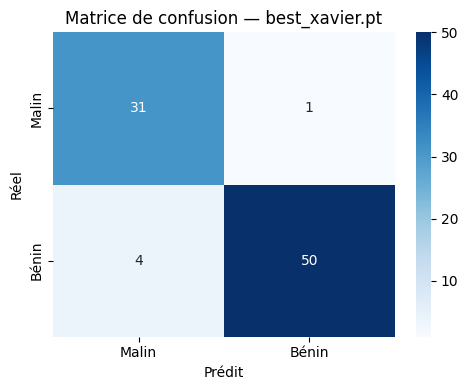

In [ ]:
# ============================================================
# RECHARGEMENT DU MEILLEUR MODÈLE ET ÉVALUATION FINALE
# ============================================================

def evaluate(model_path, model_class, test_loader):
    """Recharge un modèle depuis le disque et l'évalue sur le test set."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model_class().to(device)
    # load_state_dict charge uniquement les paramètres (pas le code Python)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec  = recall_score(all_labels, all_preds, average='macro')
    f1   = f1_score(all_labels, all_preds, average='macro')
    cm   = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # Matrice de confusion
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malin','Bénin'],
                yticklabels=['Malin','Bénin'])
    plt.title(f"Matrice de confusion — {model_path}")
    plt.ylabel("Réel"); plt.xlabel("Prédit")
    plt.tight_layout(); plt.show()

    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1}

print("=== Meilleur modèle Xavier (recommandé) ===")
results = evaluate("best_xavier.pt", MLP, test_loader)

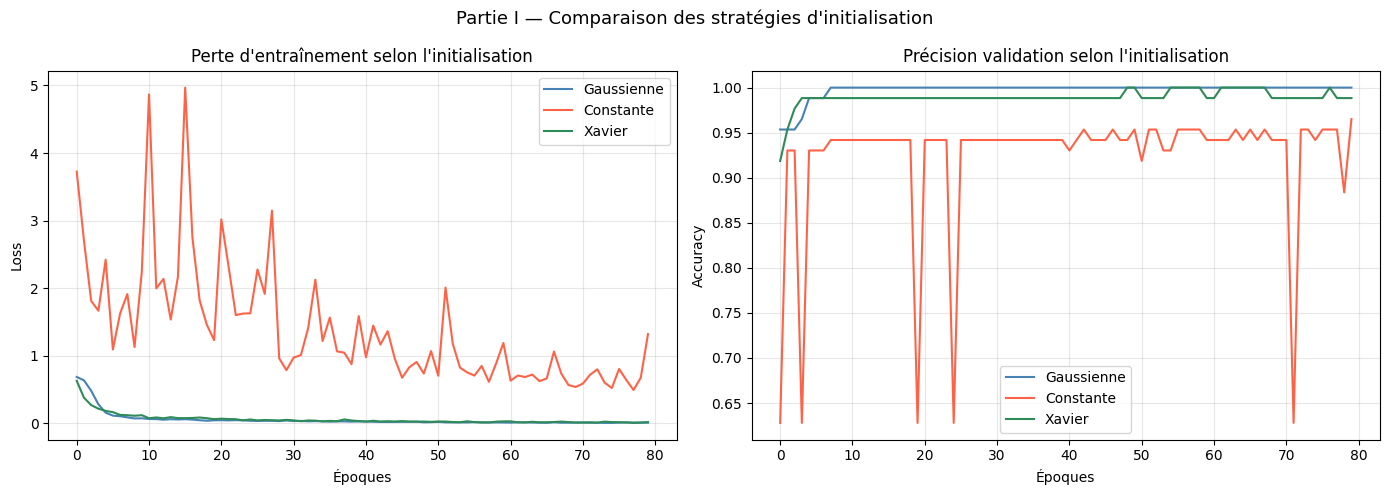

In [ ]:
# ============================================================
# VISUALISATION : comparaison des 3 initialisations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (hist_gauss,  "Gaussienne", "steelblue"),
    (hist_const,  "Constante",  "tomato"),
    (hist_xavier, "Xavier",     "seagreen")
]:
    axes[0].plot(hist["train_loss"], label=label, color=color)
    axes[1].plot(hist["val_acc"],    label=label, color=color)

axes[0].set_title("Perte d'entraînement selon l'initialisation")
axes[0].set_xlabel("Époques"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("Précision validation selon l'initialisation")
axes[1].set_xlabel("Époques"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Partie I — Comparaison des stratégies d'initialisation", fontsize=13)
plt.tight_layout(); plt.show()